<a href="https://colab.research.google.com/github/OmkarRameshJadhav108/-OpenEdHub-Open-Source-Online-Learning-Platform/blob/main/IMDB_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [26]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("IMDB_Dataset.csv", encoding="latin1", on_bad_lines='skip')

df.head()





Saving IMDB_Dataset.csv to IMDB_Dataset (5).csv


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


uploaded = files.upload()

df = pd.read_csv("IMDB_Dataset.csv", encoding="latin1", on_bad_lines='skip')

df.head()

In [27]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

df = df.dropna()

print(df['sentiment'].value_counts())

sentiment
0.0    24824
1.0    24815
Name: count, dtype: int64


In [28]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['review'] = df['review'].apply(clean_text)

In [29]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['review']).toarray()
y = df['sentiment']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.8678 - loss: 0.3099 - val_accuracy: 0.8861 - val_loss: 0.2772
Epoch 2/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9060 - loss: 0.2293 - val_accuracy: 0.8837 - val_loss: 0.2801
Epoch 3/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9266 - loss: 0.1822 - val_accuracy: 0.8808 - val_loss: 0.3009
Epoch 4/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9686 - loss: 0.0934 - val_accuracy: 0.8744 - val_loss: 0.4451
Epoch 5/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9918 - loss: 0.0262 - val_accuracy: 0.8725 - val_loss: 0.5469
Epoch 6/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9991 - loss: 0.0050 - val_accuracy: 0.8721 - val_loss: 0.7654
Epoch 7/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 1.0000 - loss: 8.8088e-04 - val_accuracy: 0.8733 - val_loss: 0.9568
Epoch 8/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 1.00

In [33]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Final Accuracy:", accuracy)


311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8760 - loss: 1.2256
Final Accuracy: 0.8760072588920593


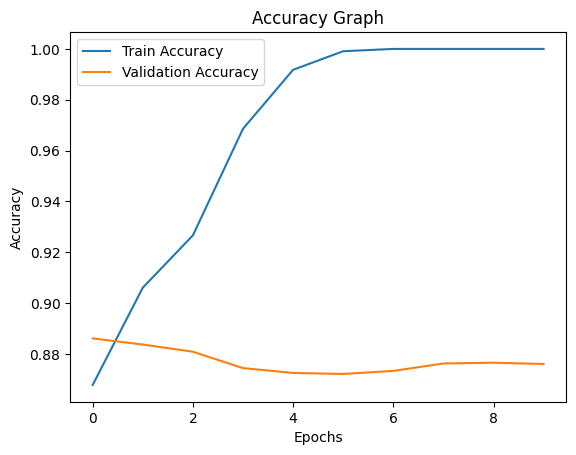

In [34]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()